# 07 — Cost per Successful Task

## Question

Across the models in the published JSON-extraction benchmark, what does one
*successful* task cost, and how much does that spread across models?

Cost per successful task is `costPerTask / successRate`. It is the number a
production system actually pays against, because failed calls are still paid for.

**Critical disclosure.** The published benchmark file carries `"isModeled": true`
and a methodology note stating the figures are a MODELED estimate derived from
public list prices plus assumed success and latency — not a live measurement. Every
number below is labelled accordingly, and the label is carried in the output itself.


## Dataset

Two files from the separate repository `harpd-dev/llm-cost-benchmark`:

| Item | Value |
|---|---|
| Benchmark | `data/2026-08-json-extraction.json` — 8 models, 100 tasks |
| Pricing | `pricing/llm-pricing.json` — 16 model list-price records |
| Task | Structured JSON extraction from messy natural-language input (en + ja + zh) |
| `isModeled` | `true` |
| Raw base | `https://raw.githubusercontent.com/harpd-dev/llm-cost-benchmark/main/` |
| Licence | MIT (code), CC BY 4.0 (data) |

Override the base for offline runs with `HARPD_BENCHMARK_BASE`.

**Domain caveat.** Rank Points are promotional placement bought with Credits — NOT
an editorial quality score. This notebook does not use Rank Points at all; it is
included here because the caveat applies repo-wide.


## Method

1. Load the benchmark results and the list-price snapshot, preserving the source's
   `isModeled` flag and methodology note.
2. `analysis.cost_per_successful_task` **recomputes** `costPerTask / successRate`
   and compares it against the published `costPerSuccessfulTask`, so the published
   figure is verified rather than trusted.
3. `analysis.benchmark_efficiency` reports the cheapest and most expensive model and
   the spread between them.
4. Reconstruct `costPerTask` from token counts and list prices for models present in
   both files, as an independent arithmetic check on the price snapshot.
5. Report unmatched models explicitly rather than dropping them silently.


## Analysis

In [1]:
import os
import sys
from pathlib import Path

# Make the repository root importable no matter where Jupyter was started.
ROOT = Path.cwd()
while not (ROOT / "harpd_research").is_dir() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from harpd_research import analysis, loader

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)

print("repo root :", ROOT)
print("data base :", loader.resolved_data_base())
print("pandas    :", pd.__version__)
print()
print("DOMAIN CAVEAT")
print(analysis.PLACEMENT_CAVEAT)


repo root : /Users/shankou/harpd/harpd-ai-research-notebooks
data base : https://raw.githubusercontent.com/harpd-dev/harpd-ai-datasets/main/
pandas    : 3.0.5

DOMAIN CAVEAT
Rank Points are promotional placement bought with Credits — NOT an editorial quality score. Any ordering below is a promotional placement ordering, not a ranking of product quality.


In [2]:

BENCH_BASE = os.environ.get(
    "HARPD_BENCHMARK_BASE",
    "https://raw.githubusercontent.com/harpd-dev/llm-cost-benchmark/main/",
)

results, meta = loader.load_benchmark_results(base=BENCH_BASE)
pricing = loader.load_llm_pricing(base=BENCH_BASE)

print("benchmark :", meta.get("benchmark"), "|", meta.get("title"))
print("taskCount :", meta.get("taskCount"))
print("generatedAt:", meta.get("generatedAt"))
print("isModeled :", meta.get("isModeled"))
print()
print("METHODOLOGY NOTE (verbatim from the dataset):")
print(" ", meta.get("methodologyNote"))
print()
print("models in benchmark :", len(results))
print("models in pricing   :", len(pricing))

benchmark : json-extraction-v1 | JSON extraction — Claude vs GPT vs Gemini vs DeepSeek
taskCount : 100
generatedAt: 2026-08-18T02:33:58.678Z
isModeled : True

METHODOLOGY NOTE (verbatim from the dataset):
  MODELED ESTIMATE. Prices are public 2026 list prices; success/latency are assumed from published 2025–2026 behavior. Replace with live runs via the open-source runner (node runner/index.mjs) before citing.

models in benchmark : 8
models in pricing   : 16


In [3]:
display(results[["model", "successRate", "costPerTask", "costPerSuccessfulTask",
                  "p50LatencyMs", "p95LatencyMs"]])

,model,successRate,costPerTask,costPerSuccessfulTask,p50LatencyMs,p95LatencyMs
0,gpt-4o-mini,0.88,0.000960,0.001091,400,900
1,deepseek-v3,0.91,0.001740,0.001912,900,2100
2,gemini-2.5-flash,0.90,0.002700,0.003000,350,800
3,llama-3.1-70b,0.84,0.004048,0.004819,700,1700
4,claude-haiku-4,0.93,0.005600,0.006022,600,1400
5,gemini-2.5-pro,0.95,0.011000,0.011579,1400,3000
6,gpt-4.1,0.96,0.012800,0.013333,1500,3200
7,claude-sonnet-4,0.97,0.021000,0.021649,1200,2600


In [4]:
# Recompute cost per successful task from the raw fields and compare with the
# published value. A non-zero delta would mean the published figure is not the
# quotient of the fields shown.
efficiency_table = analysis.cost_per_successful_task(results, meta)

display(efficiency_table[["efficiencyOrder", "model", "successRate", "costPerTask",
                          "costPerSuccessfulTask", "publishedCostPerSuccessfulTask",
                          "recomputedDeltaPct", "isModeled"]])

max_delta = efficiency_table["recomputedDeltaPct"].max()
print(f"max |recomputed - published| : {max_delta}%")
print("recomputation consistent with published values:", bool(max_delta < 0.01))

,efficiencyOrder,model,successRate,costPerTask,costPerSuccessfulTask,publishedCostPerSuccessfulTask,recomputedDeltaPct,isModeled
0,1,gpt-4o-mini,0.88,0.000960,0.001091,0.001091,0.0,True
1,2,deepseek-v3,0.91,0.001740,0.001912,0.001912,0.0,True
2,3,gemini-2.5-flash,0.90,0.002700,0.003000,0.003000,0.0,True
3,4,llama-3.1-70b,0.84,0.004048,0.004819,0.004819,0.0,True
4,5,claude-haiku-4,0.93,0.005600,0.006022,0.006022,0.0,True
5,6,gemini-2.5-pro,0.95,0.011000,0.011579,0.011579,0.0,True
6,7,gpt-4.1,0.96,0.012800,0.013333,0.013333,0.0,True
7,8,claude-sonnet-4,0.97,0.021000,0.021649,0.021649,0.0,True


max |recomputed - published| : 0.0%
recomputation consistent with published values: True


In [5]:
summary = analysis.benchmark_efficiency(efficiency_table)
for key, value in summary.items():
    print(f"{key:36s}: {value}")

models                              : 8
cheapestModel                       : gpt-4o-mini
cheapestCostPerSuccessfulTask       : 0.001091
mostExpensiveModel                  : claude-sonnet-4
mostExpensiveCostPerSuccessfulTask  : 0.021649
costSpreadRatio                     : 19.84
maxSuccessRate                      : 0.97
minSuccessRate                      : 0.84
hasData                             : True


In [6]:
# Independent check: rebuild costPerTask from token counts and list prices.
def norm(s):
    return str(s).strip().lower().replace(".", "-").replace(" ", "-")
pricing_lookup = {norm(r["id"]): r for _, r in pricing.iterrows()}

rows = []
for _, r in results.iterrows():
    key = norm(r["model"])
    price = pricing_lookup.get(key)
    if price is None:
        rows.append({"model": r["model"], "pricing_id": None, "matched": False,
                     "rebuilt_costPerTask": None, "published_costPerTask": r["costPerTask"],
                     "deltaPct": None})
        continue
    rebuilt = (
        r["avgInputTokens"] * price["input_per_million"]
        + r["avgOutputTokens"] * price["output_per_million"]
    ) / 1e6
    delta = abs(rebuilt - r["costPerTask"]) / r["costPerTask"] * 100
    rows.append({"model": r["model"], "pricing_id": price["id"], "matched": True,
                 "rebuilt_costPerTask": round(rebuilt, 6),
                 "published_costPerTask": r["costPerTask"],
                 "deltaPct": round(delta, 4)})

rebuild = pd.DataFrame(rows)
display(rebuild)

matched = int(rebuild["matched"].sum())
unmatched = rebuild.loc[~rebuild["matched"], "model"].tolist()
print(f"matched to a pricing record : {matched} of {len(rebuild)}")
print(f"unmatched models            : {unmatched}")
if matched:
    print(f"max rebuild delta           : {rebuild['deltaPct'].max()}%")
    print("rebuilt costs consistent with published costs:",
          bool(rebuild.loc[rebuild['matched'], 'deltaPct'].max() < 0.01))

,model,pricing_id,matched,rebuilt_costPerTask,published_costPerTask,deltaPct
0,gpt-4o-mini,NaN,False,NaN,0.000960,NaN
1,deepseek-v3,deepseek-v3,True,0.001740,0.001740,0.0
2,gemini-2.5-flash,gemini-2-5-flash,True,0.002700,0.002700,0.0
3,llama-3.1-70b,llama-3-1-70b,True,0.004048,0.004048,0.0
4,claude-haiku-4,NaN,False,NaN,0.005600,NaN
5,gemini-2.5-pro,gemini-2-5-pro,True,0.011000,0.011000,0.0
6,gpt-4.1,gpt-4-1,True,0.012800,0.012800,0.0
7,claude-sonnet-4,NaN,False,NaN,0.021000,NaN


matched to a pricing record : 5 of 8
unmatched models            : ['gpt-4o-mini', 'claude-haiku-4', 'claude-sonnet-4']
max rebuild delta           : 0.0%
rebuilt costs consistent with published costs: True


## Visualization

Left: cost per successful task per model, ordered cheapest first — this is a **cost
ordering**, and it says nothing about output quality beyond the benchmark's own
exact-match success check. Right: success rate against cost, which shows the
trade-off the benchmark is measuring.


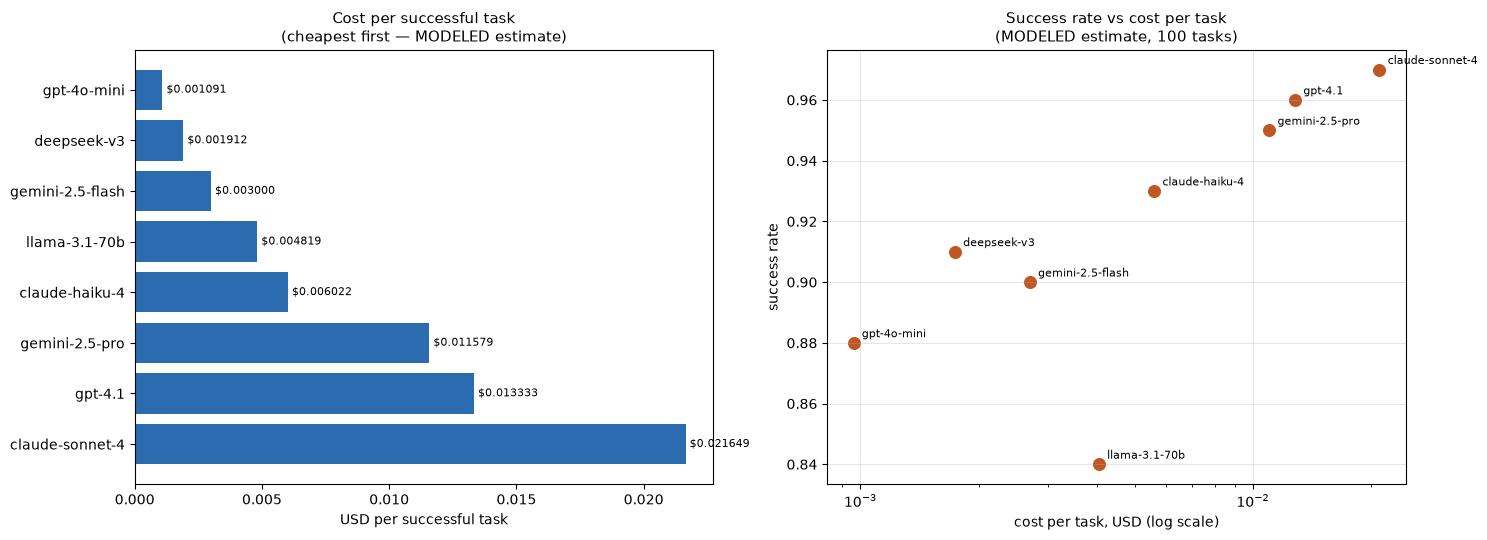

Every value above is a MODELED estimate published by the dataset author.
Source methodology note: MODELED ESTIMATE. Prices are public 2026 list prices; success/latency are assumed from published 2025–2026 behavior. Replace with live runs via the open-source runner (node runner/index.mjs) before citing.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ordered = efficiency_table.iloc[::-1]
axes[0].barh(ordered["model"], ordered["costPerSuccessfulTask"], color="#2b6cb0")
axes[0].set_xlabel("USD per successful task")
axes[0].set_title("Cost per successful task\n(cheapest first — MODELED estimate)", fontsize=11)
for y, v in enumerate(ordered["costPerSuccessfulTask"]):
    axes[0].text(v, y, f" ${v:.6f}", va="center", fontsize=8)

axes[1].scatter(results["costPerTask"], results["successRate"], s=70, color="#c05621")
for _, r in results.iterrows():
    axes[1].annotate(r["model"], (r["costPerTask"], r["successRate"]),
                     textcoords="offset points", xytext=(6, 4), fontsize=8)
axes[1].set_xscale("log")
axes[1].set_xlabel("cost per task, USD (log scale)")
axes[1].set_ylabel("success rate")
axes[1].set_title("Success rate vs cost per task\n(MODELED estimate, 100 tasks)", fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Every value above is a MODELED estimate published by the dataset author.")
print("Source methodology note:", meta.get("methodologyNote"))

## Findings

In [8]:
cheapest = efficiency_table.iloc[0]
dearest = efficiency_table.iloc[-1]
best_success = results.loc[results["successRate"].idxmax()]

findings = [
    f"Across {len(results)} models the cheapest successful task costs "
    f"${cheapest['costPerSuccessfulTask']:.6f} ({cheapest['model']}) and the most "
    f"expensive costs ${dearest['costPerSuccessfulTask']:.6f} ({dearest['model']}) — "
    f"a spread of {summary['costSpreadRatio']}x.",

    f"Success rates span {summary['minSuccessRate']:.2f} to "
    f"{summary['maxSuccessRate']:.2f}; the highest is {best_success['model']} at "
    f"{best_success['successRate']:.2f}.",

    f"Recomputing costPerTask / successRate reproduces the published "
    f"costPerSuccessfulTask to within {max_delta}%, so the published column is the "
    "quotient of the fields shown and is not an independent figure.",

    f"Rebuilding costPerTask from token counts and list prices matched {matched} of "
    f"{len(rebuild)} models. The {len(unmatched)} unmatched models "
    f"({', '.join(unmatched) if unmatched else 'none'}) have no counterpart in the "
    "price snapshot, so their cost cannot be independently checked here.",

    "The benchmark's own metadata marks these figures a MODELED estimate built from "
    "public list prices plus assumed success and latency. They are not live "
    "measurements and must not be cited as measured results.",

    "Cost per successful task differs from cost per task by a factor of "
    "1/successRate, which is at most "
    f"{1/summary['minSuccessRate']:.3f}x here. Ignoring failures understates the "
    "true cost of a working pipeline by that factor.",

    "This benchmark covers one task family (JSON extraction). The ranking of models "
    "by cost per successful task is specific to that task and does not transfer to "
    "other workloads.",
]

for i, line in enumerate(findings, 1):
    print(f"{i}. {line}")

1. Across 8 models the cheapest successful task costs $0.001091 (gpt-4o-mini) and the most expensive costs $0.021649 (claude-sonnet-4) — a spread of 19.84x.
2. Success rates span 0.84 to 0.97; the highest is claude-sonnet-4 at 0.97.
3. Recomputing costPerTask / successRate reproduces the published costPerSuccessfulTask to within 0.0%, so the published column is the quotient of the fields shown and is not an independent figure.
4. Rebuilding costPerTask from token counts and list prices matched 5 of 8 models. The 3 unmatched models (gpt-4o-mini, claude-haiku-4, claude-sonnet-4) have no counterpart in the price snapshot, so their cost cannot be independently checked here.
5. The benchmark's own metadata marks these figures a MODELED estimate built from public list prices plus assumed success and latency. They are not live measurements and must not be cited as measured results.
6. Cost per successful task differs from cost per task by a factor of 1/successRate, which is at most 1.190x her

## Limitations

- **These are MODELED estimates, not measurements.** The dataset sets
  `"isModeled": true`. Prices are real published list prices; success rates and
  latencies are assumed. Replace them with live runs via the repository's runner
  before citing them as measured.
- One task family, 100 tasks, temperature 0. Results are specific to JSON
  extraction and do not generalise to other workloads.
- Only 5 of 8 benchmark models appear in the price snapshot, so the independent
  price check covers a majority but not all of the table. The unmatched models are
  named rather than dropped.
- Prices change. The snapshot is dated 2026-08-18 and the pricing file itself warns
  that some rates are approximate (for example DeepSeek's peak/off-peak change).
- List prices exclude retries, prompt overhead, caching benefits, batch discounts
  and infrastructure cost, so real spend will differ from these figures.
- A low cost per successful task is not a recommendation. Model choice also depends
  on output quality, latency and data-handling constraints, none of which this
  dataset measures beyond exact-match success.
- Cost per successful task assumes failures are simply retried at the same rate. A
  production pipeline with retry logic or fallbacks will have a different profile.


## Reproducibility

In [9]:
import platform
import sys

print("Reproduce this notebook")
print("=" * 60)
print("python :", sys.version.split()[0], "on", platform.platform())
print("pandas :", pd.__version__)
print("data   :", loader.resolved_data_base())
print()
print("From a clean machine:")
print("  git clone https://github.com/harpd-dev/harpd-ai-research-notebooks")
print("  cd harpd-ai-research-notebooks")
print("  python -m venv .venv && . .venv/bin/activate")
print("  pip install -r requirements.txt")
print("  jupyter nbconvert --to notebook --execute --inplace notebooks/<this file>")
print()
print("Offline / pinned snapshot:")
print("  HARPD_DATA_BASE=/path/to/harpd-ai-datasets/ jupyter nbconvert ...")

print()
print("This notebook reads a separate repository:")
print("  HARPD_BENCHMARK_BASE =", BENCH_BASE)
print("  gh repo clone harpd-dev/llm-cost-benchmark /tmp/llm-cost-benchmark -- --depth 1")


Reproduce this notebook
python : 3.13.12 on macOS-26.6.2-arm64-arm-64bit-Mach-O
pandas : 3.0.5
data   : https://raw.githubusercontent.com/harpd-dev/harpd-ai-datasets/main/

From a clean machine:
  git clone https://github.com/harpd-dev/harpd-ai-research-notebooks
  cd harpd-ai-research-notebooks
  python -m venv .venv && . .venv/bin/activate
  pip install -r requirements.txt
  jupyter nbconvert --to notebook --execute --inplace notebooks/<this file>

Offline / pinned snapshot:
  HARPD_DATA_BASE=/path/to/harpd-ai-datasets/ jupyter nbconvert ...

This notebook reads a separate repository:
  HARPD_BENCHMARK_BASE = https://raw.githubusercontent.com/harpd-dev/llm-cost-benchmark/main/
  gh repo clone harpd-dev/llm-cost-benchmark /tmp/llm-cost-benchmark -- --depth 1


## Sources

- Benchmark repository: <https://github.com/harpd-dev/llm-cost-benchmark>
- Benchmark data: `data/2026-08-json-extraction.json`
- Pricing snapshot: `pricing/llm-pricing.json`
- Publisher benchmark page: <https://harpd.com/benchmarks/>
- Publisher methodology: <https://harpd.com/methodology/benchmarks/>
- Cost-per-successful-task concept (publisher): <https://harpd.com/cost-per-successful-task/>
- Canonical data home: <https://harpd.com/data/>
- Licence: MIT (code), CC BY 4.0 (data)

**Licence.** All Harpd dataset content is published under CC BY 4.0.

**Attribution.** Harpd (<https://harpd.com>).

**Not a source for.** Product quality, traffic, revenue, review scores or
market size. None of those are measured by these datasets, and none are
estimated in this notebook.
